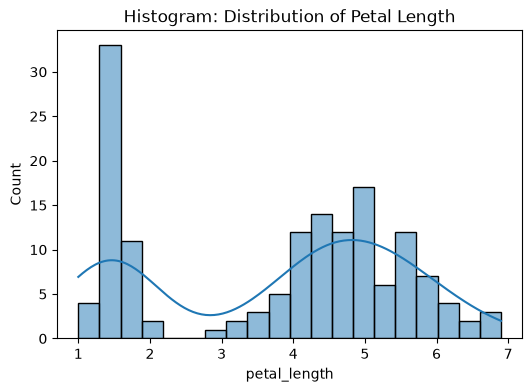

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. ensemble import RandomForestClassifier
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
df = sns.load_dataset("iris")

# 1. Histogram + Distribusi
plt.figure(figsize=(6,4))
sns.histplot(df['petal_length' ], bins=20, kde=True)
plt.title("Histogram: Distribution of Petal Length")
plt.show()

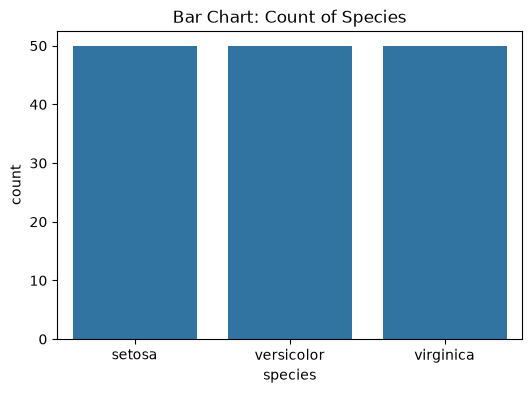

In [2]:
# 2. Bar Chart - Count per category
plt.figure(figsize=(6,4))
sns.countplot (x="species", data=df)
plt.title("Bar Chart: Count of Species")
plt.show()

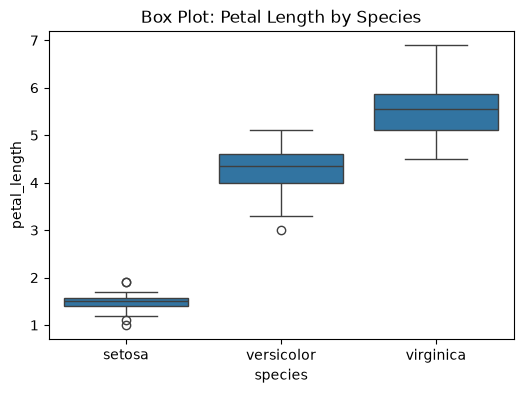

In [3]:
# 3. Box Plot - Spread + Outlier detection
plt.figure(figsize=(6,4))
sns .boxplot (x="species", y="petal_length", data=df)
plt.title("Box Plot: Petal Length by Species")
plt.show()

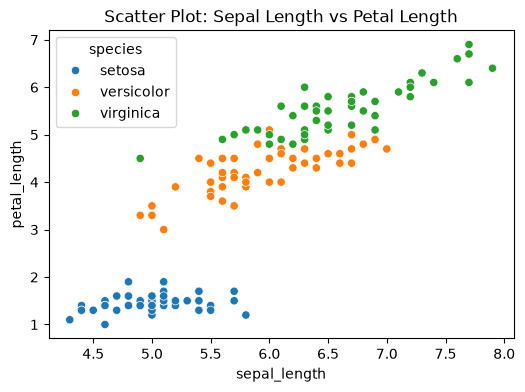

In [4]:
# 4. Scatter Plot + Relationship
plt.figure(figsize=(6,4))

sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()

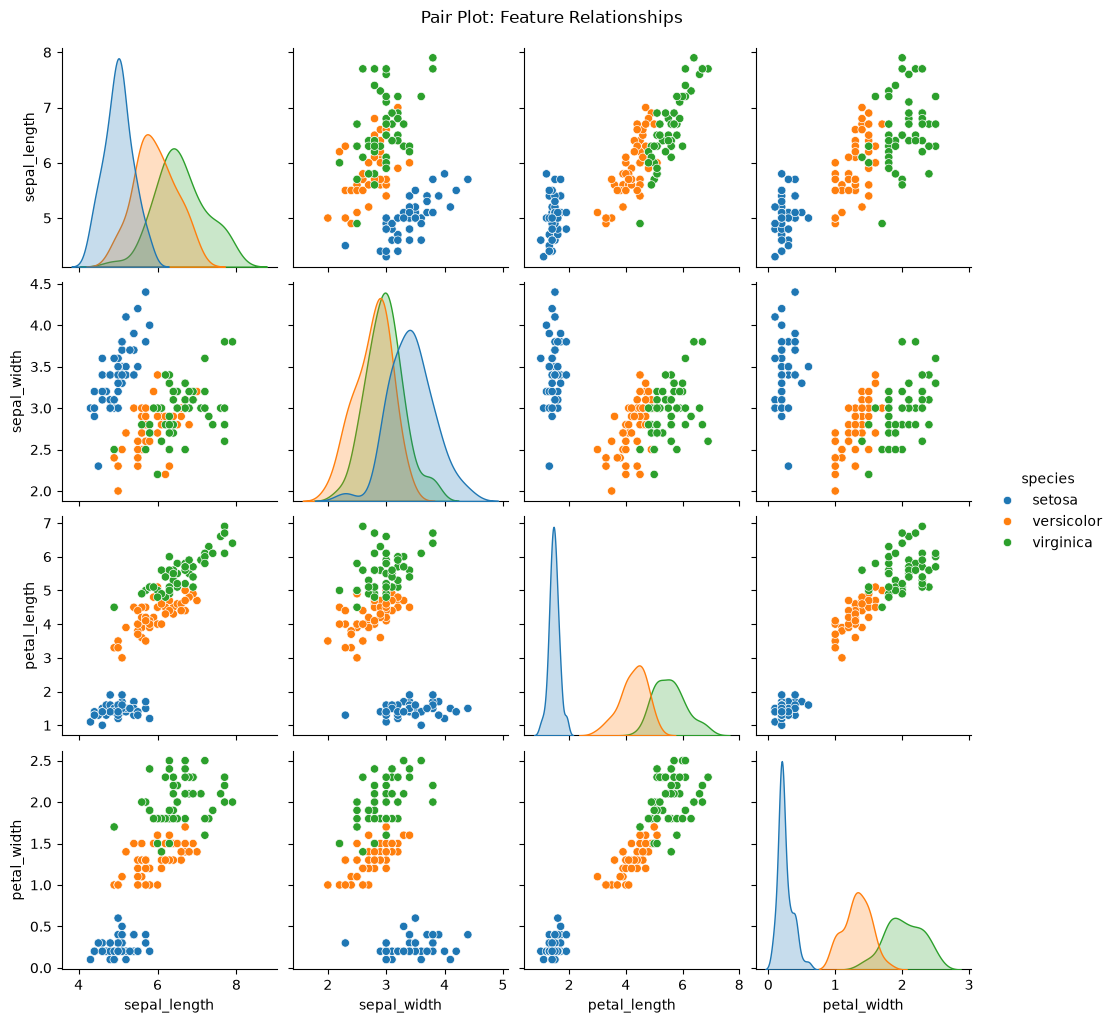

In [5]:
# 5. Pair Plot + Multivariate relationship
sns.pairplot(df, hue="species")
plt.suptitle("Pair Plot: Feature Relationships", y=1.02)
plt.show()

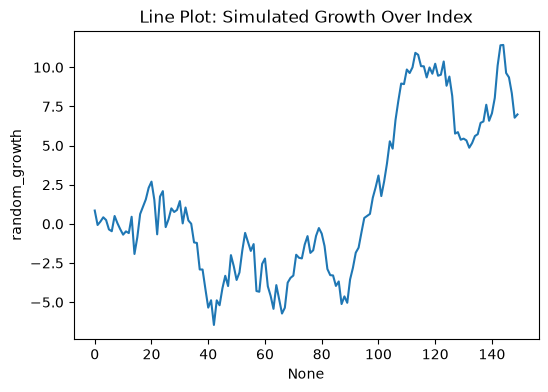

In [6]:
# 6. Line Plot - Example time series (simulate cumulative sum)
plt.figure(figsize=(6,4))
df["random_growth"] = np.random.randn(len(df)).cumsum()
sns. lineplot(x=df. index, y="random_growth", data=df)
plt.title("Line Plot: Simulated Growth Over Index")
plt.show()

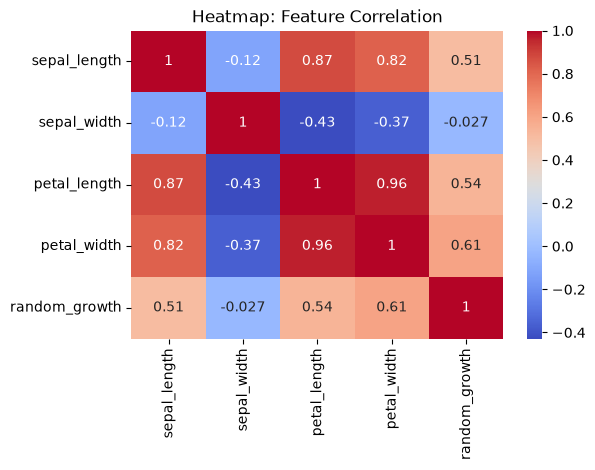

In [7]:
# 7. Heatmap + Correlation matrix
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap: Feature Correlation")
plt.show()

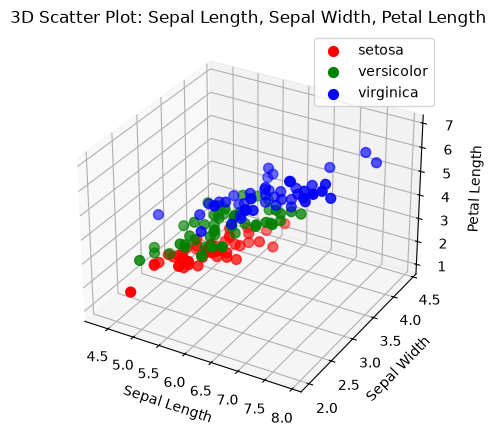

In [25]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

# Mengambil jenis species
species = df["species"].unique()

# Warna untuk setiap species
colors = ["r", "g", "b"]

# Membuat scatter plot untuk setiap species
for sp, col in zip(species, colors):
    subset = df[df["species"] == sp]

    ax.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        subset["petal_length"],
        c=col,
        label=sp,
        s=50
)

# Label sumbu
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

# Judul
ax.set_title(
    "3D Scatter Plot: Sepal Length, Sepal Width, Petal Length"
)

# Legend
ax.legend()

# Menampilkan grafik
plt.show()

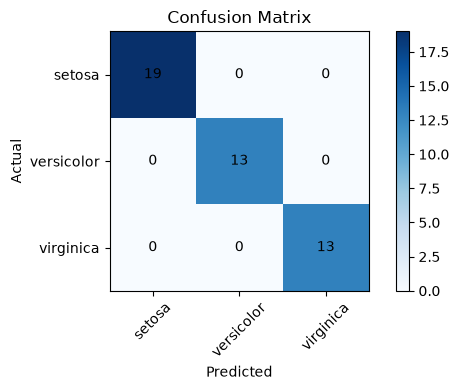

In [28]:
X = df.drop("species", axis=1)
y = df["species"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(6, 4))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.colorbar()

# Label sumbu X
plt.xticks(
    range(len(model.classes_)),
    model.classes_,
    rotation=45
)

# Label sumbu Y
plt.yticks(
    range (len(model.classes_)),
    model.classes_
)

# Menampilkan nilai confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

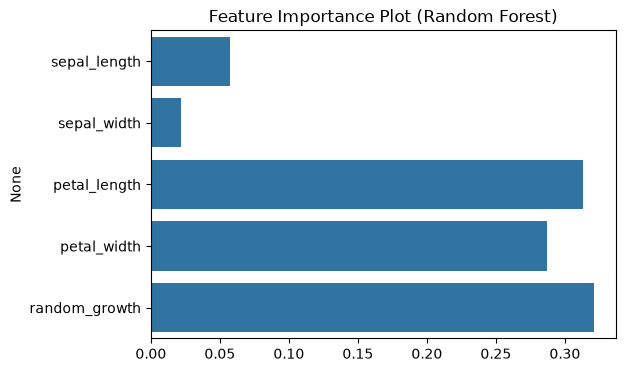

In [38]:
# 9.3. Feature Importance Plot + Random Forest
X = df.drop("species", axis=1)
y = df["species"]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model. feature_importances_
features = X. columns

plt.figure(figsize=(6,4))
sns.barplot (x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()